# Notebook 06: Comprehensive Comparison (Baseline vs TPE vs GWO)

**Objective:** Aggregate and compare results from three stages:
- Baseline (Notebook 03)
- TPE optimization (Notebook 04a)
- GWO optimization (Notebook 05b)

This notebook performs **structured comparison only**:
- ✅ Load pre-computed results
- ✅ Create unified comparison datasets
- ✅ Compute descriptive statistics and improvements
- ✅ Generate publication-quality visualizations (Priority: CV > Convergence > Runtime)
- ✅ Prepare data for statistical testing (Notebook 07)



In [3]:
# Imports and Configuration
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add utils to path for plot_config
sys.path.insert(0, os.path.abspath('..'))
from utils.plot_config import apply_plot_style, CB_BLUE, CB_ORANGE, IEEE_SINGLE_COL, IEEE_DOUBLE_COL, clean_ax

# Set up paths
results_dir = Path('../results/tables')
figures_dir = Path('../results/figures')
figures_dir.mkdir(exist_ok=True)

print("✓ Imports loaded successfully")
print(f"✓ Results directory: {results_dir}")
print(f"✓ Figures directory: {figures_dir}")

✓ Imports loaded successfully
✓ Results directory: ..\results\tables
✓ Figures directory: ..\results\figures


## Phase 1: Data Loading and Validation

Load all pre-computed results from Baseline, TPE, and GWO optimizations.

In [4]:
# 1.1 Load all input files

# Baseline
baseline_cv = pd.read_csv(results_dir / 'optimal_scaler_fold_scores.csv')
baseline_test = pd.read_csv(results_dir / 'baseline_test_results_clean.csv')
baseline_inference = pd.read_csv(results_dir / 'baseline_inference_time.csv')

# TPE
tpe_cv = pd.read_csv(results_dir / 'TPE_optimal_fold_scores.csv')
tpe_test = pd.read_csv(results_dir / 'TPE_test_results.csv')
tpe_optimization = pd.read_csv(results_dir / 'TPE_optimization_time.csv')
tpe_convergence = pd.read_csv(results_dir / 'TPE_convergence.csv')

# GWO
gwo_cv = pd.read_csv(results_dir / 'GWO_optimal_fold_scores.csv')
gwo_test = pd.read_csv(results_dir / 'GWO_test_results.csv')
gwo_optimization = pd.read_csv(results_dir / 'GWO_optimization_time.csv')
gwo_convergence = pd.read_csv(results_dir / 'GWO_convergence.csv')

print("✓ All data files loaded successfully")
print(f"\nBaseline CV shape: {baseline_cv.shape}")
print(f"TPE CV shape: {tpe_cv.shape}")
print(f"GWO CV shape: {gwo_cv.shape}")

# 1.2 Validation: Check all 14 models present and consistent
baseline_models = set(baseline_cv['Model'].unique())
tpe_models = set(tpe_cv['Model'].unique())
gwo_models = set(gwo_cv['Model'].unique())

print(f"\nBaseline models: {len(baseline_models)}")
print(f"TPE models: {len(tpe_models)}")
print(f"GWO models: {len(gwo_models)}")

assert baseline_models == tpe_models == gwo_models, "Model sets do not match across methods!"
assert len(baseline_models) == 14, f"Expected 14 models, got {len(baseline_models)}"

print(f"✓ All 14 models consistent across methods: {sorted(baseline_models)}")

# 1.3 Validation: Check CV fold column structure
cv_fold_cols = ['Fold_1', 'Fold_2', 'Fold_3', 'Fold_4', 'Fold_5', 'Mean', 'Std']
assert all(col in baseline_cv.columns for col in cv_fold_cols), "Missing CV fold columns in Baseline"
assert all(col in tpe_cv.columns for col in cv_fold_cols), "Missing CV fold columns in TPE"
assert all(col in gwo_cv.columns for col in cv_fold_cols), "Missing CV fold columns in GWO"
print(f"✓ All CV fold columns present: {cv_fold_cols}")

# 1.4 Validation: Check test metrics columns
test_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'LogLoss', 'Kappa', 'MCC']
assert all(col in baseline_test.columns for col in test_metrics), "Missing test metrics in Baseline"
assert all(col in tpe_test.columns for col in test_metrics), "Missing test metrics in TPE"
assert all(col in gwo_test.columns for col in test_metrics), "Missing test metrics in GWO"
print(f"✓ All test metrics present: {test_metrics}")

# 1.5 Validation: No unexpected missing values in key metrics
for df, name in [(baseline_cv, "Baseline CV"), (tpe_cv, "TPE CV"), (gwo_cv, "GWO CV")]:
    missing_in_mean = df[['Fold_1', 'Fold_2', 'Fold_3', 'Fold_4', 'Fold_5', 'Mean']].isna().sum().sum()
    assert missing_in_mean == 0, f"{name} has missing values in fold metrics"
print(f"✓ No missing values in CV fold metrics")

print("\n" + "="*60)
print("DATA VALIDATION COMPLETE ✓")
print("="*60)

✓ All data files loaded successfully

Baseline CV shape: (14, 9)
TPE CV shape: (14, 9)
GWO CV shape: (14, 9)

Baseline models: 14
TPE models: 14
GWO models: 14
✓ All 14 models consistent across methods: ['AdaBoost', 'CB', 'GB', 'KNN', 'LDA', 'LGBM', 'LR', 'LinearSVC', 'NB', 'QDA', 'RF', 'SGD', 'SVM', 'XGB']
✓ All CV fold columns present: ['Fold_1', 'Fold_2', 'Fold_3', 'Fold_4', 'Fold_5', 'Mean', 'Std']
✓ All test metrics present: ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'LogLoss', 'Kappa', 'MCC']
✓ No missing values in CV fold metrics

DATA VALIDATION COMPLETE ✓


In [5]:
# 1.2 Create unified CV scores dataset
# Structure: Model | Method | Fold_1 | ... | Fold_5 | Mean | Std (42 rows: 14 models × 3 methods)

cv_comparison_list = []

for model in sorted(baseline_models):
    # Baseline
    baseline_row = baseline_cv[baseline_cv['Model'] == model].iloc[0]
    baseline_record = {
        'Model': model,
        'Method': 'Baseline',
        'Fold_1': baseline_row['Fold_1'],
        'Fold_2': baseline_row['Fold_2'],
        'Fold_3': baseline_row['Fold_3'],
        'Fold_4': baseline_row['Fold_4'],
        'Fold_5': baseline_row['Fold_5'],
        'Mean': baseline_row['Mean'],
        'Std': baseline_row['Std'],
    }
    cv_comparison_list.append(baseline_record)
    
    # TPE
    tpe_row = tpe_cv[tpe_cv['Model'] == model].iloc[0]
    tpe_record = {
        'Model': model,
        'Method': 'TPE',
        'Fold_1': tpe_row['Fold_1'],
        'Fold_2': tpe_row['Fold_2'],
        'Fold_3': tpe_row['Fold_3'],
        'Fold_4': tpe_row['Fold_4'],
        'Fold_5': tpe_row['Fold_5'],
        'Mean': tpe_row['Mean'],
        'Std': tpe_row['Std'],
    }
    cv_comparison_list.append(tpe_record)
    
    # GWO
    gwo_row = gwo_cv[gwo_cv['Model'] == model].iloc[0]
    gwo_record = {
        'Model': model,
        'Method': 'GWO',
        'Fold_1': gwo_row['Fold_1'],
        'Fold_2': gwo_row['Fold_2'],
        'Fold_3': gwo_row['Fold_3'],
        'Fold_4': gwo_row['Fold_4'],
        'Fold_5': gwo_row['Fold_5'],
        'Mean': gwo_row['Mean'],
        'Std': gwo_row['Std'],
    }
    cv_comparison_list.append(gwo_record)

comparison_cv_scores = pd.DataFrame(cv_comparison_list)

# Save to CSV
comparison_cv_scores.to_csv(results_dir / 'comparison_cv_scores.csv', index=False)

print("✓ Created unified CV scores dataset")
print(f"Shape: {comparison_cv_scores.shape} (14 models × 3 methods)")
print(f"Saved to: comparison_cv_scores.csv\n")
print(comparison_cv_scores.head(15))

✓ Created unified CV scores dataset
Shape: (42, 9) (14 models × 3 methods)
Saved to: comparison_cv_scores.csv

       Model    Method    Fold_1    Fold_2    Fold_3    Fold_4    Fold_5  \
0   AdaBoost  Baseline  0.890312  0.896042  0.874687  0.889167  0.887604   
1   AdaBoost       TPE  0.951146  0.950313  0.949479  0.949792  0.950729   
2   AdaBoost       GWO  0.952187  0.952187  0.952396  0.950729  0.952500   
3         CB  Baseline  0.988542  0.986875  0.987604  0.989792  0.989583   
4         CB       TPE  0.994479  0.995417  0.995000  0.995938  0.994792   
5         CB       GWO  0.996042  0.995104  0.995104  0.996458  0.994687   
6         GB  Baseline  0.918125  0.926667  0.925104  0.925521  0.917500   
7         GB       TPE  0.995729  0.995000  0.995521  0.996563  0.996250   
8         GB       GWO  0.996563  0.996146  0.995729  0.997396  0.996875   
9        KNN  Baseline  0.931250  0.929479  0.937292  0.933333  0.931979   
10       KNN       TPE  0.949479  0.946354  0.950208 

In [6]:
# 1.3 Create unified test results dataset
# Structure: Model | Method | Accuracy | Precision | ... | MCC | Improvements vs Baseline

test_comparison_list = []

for model in sorted(baseline_models):
    baseline_row = baseline_test[baseline_test['Model'] == model].iloc[0]
    tpe_row = tpe_test[tpe_test['Model'] == model].iloc[0]
    gwo_row = gwo_test[gwo_test['Model'] == model].iloc[0]
    
    # Method 1: Baseline
    baseline_record = {'Model': model, 'Method': 'Baseline'}
    for metric in test_metrics:
        baseline_record[metric] = baseline_row[metric]
        baseline_record[f'{metric}_Improvement_pct'] = 0.0  # Reference point
    test_comparison_list.append(baseline_record)
    
    # Method 2: TPE (with improvements vs Baseline)
    tpe_record = {'Model': model, 'Method': 'TPE'}
    for metric in test_metrics:
        tpe_record[metric] = tpe_row[metric]
        # For metrics where higher is better (most except LogLoss), compute improvement
        if metric != 'LogLoss':
            improvement_pct = ((tpe_row[metric] - baseline_row[metric]) / baseline_row[metric] * 100) if baseline_row[metric] != 0 else 0
        else:
            # For LogLoss, lower is better
            improvement_pct = ((baseline_row[metric] - tpe_row[metric]) / baseline_row[metric] * 100) if baseline_row[metric] != 0 else 0
        tpe_record[f'{metric}_Improvement_pct'] = improvement_pct
    test_comparison_list.append(tpe_record)
    
    # Method 3: GWO (with improvements vs Baseline)
    gwo_record = {'Model': model, 'Method': 'GWO'}
    for metric in test_metrics:
        gwo_record[metric] = gwo_row[metric]
        # For metrics where higher is better (most except LogLoss), compute improvement
        if metric != 'LogLoss':
            improvement_pct = ((gwo_row[metric] - baseline_row[metric]) / baseline_row[metric] * 100) if baseline_row[metric] != 0 else 0
        else:
            # For LogLoss, lower is better
            improvement_pct = ((baseline_row[metric] - gwo_row[metric]) / baseline_row[metric] * 100) if baseline_row[metric] != 0 else 0
        gwo_record[f'{metric}_Improvement_pct'] = improvement_pct
    test_comparison_list.append(gwo_record)

comparison_test_results = pd.DataFrame(test_comparison_list)

# Save to CSV
comparison_test_results.to_csv(results_dir / 'comparison_test_results.csv', index=False)

print("✓ Created unified test results dataset")
print(f"Shape: {comparison_test_results.shape}")
print(f"Saved to: comparison_test_results.csv\n")
print(comparison_test_results.iloc[:9][['Model', 'Method', 'Accuracy', 'Accuracy_Improvement_pct', 'F1', 'F1_Improvement_pct']])

✓ Created unified test results dataset
Shape: (42, 18)
Saved to: comparison_test_results.csv

      Model    Method  Accuracy  Accuracy_Improvement_pct        F1  \
0  AdaBoost  Baseline  0.893500                  0.000000  0.917782   
1  AdaBoost       TPE  0.949667                  6.286141  0.960805   
2  AdaBoost       GWO  0.951167                  6.454020  0.961913   
3        CB  Baseline  0.992250                  0.000000  0.993942   
4        CB       TPE  0.997000                  0.478710  0.997650   
5        CB       GWO  0.997833                  0.562694  0.998302   
6        GB  Baseline  0.926250                  0.000000  0.943112   
7        GB       TPE  0.998583                  7.809267  0.998890   
8        GB       GWO  0.997167                  7.656320  0.997781   

   F1_Improvement_pct  
0            0.000000  
1            4.687704  
2            4.808512  
3            0.000000  
4            0.373097  
5            0.438725  
6            0.000000  
7  

In [8]:
# 1.4 Standardize convergence data
# Critical: TPE uses column 'Trial', GWO uses 'Iteration' → unify to 'Iteration'

print("TPE convergence columns:", tpe_convergence.columns.tolist())
print("GWO convergence columns:", gwo_convergence.columns.tolist())

convergence_comparison_list = []

for model in sorted(baseline_models):
    # TPE
    tpe_model_data = tpe_convergence[tpe_convergence['Model'] == model].copy()
    for _, row in tpe_model_data.iterrows():
        convergence_comparison_list.append({
            'Model': model,
            'Optimizer': 'TPE',
            'Iteration': row['Trial'],  # Map 'Trial' → 'Iteration'
            'Best_Score_So_Far': row['Best_Score_So_Far']
        })
    
    # GWO
    gwo_model_data = gwo_convergence[gwo_convergence['Model'] == model].copy()
    for _, row in gwo_model_data.iterrows():
        convergence_comparison_list.append({
            'Model': model,
            'Optimizer': 'GWO',
            'Iteration': row['Iteration'],
            'Best_Score_So_Far': row['Best_Score_So_Far']
        })

comparison_convergence = pd.DataFrame(convergence_comparison_list)

# Save to CSV
comparison_convergence.to_csv(results_dir / 'comparison_convergence.csv', index=False)

print("\n✓ Created unified convergence dataset")
print(f"Shape: {comparison_convergence.shape}")
print(f"Saved to: comparison_convergence.csv\n")

# Summary stats
for model in sorted(baseline_models)[:3]:  # Show first 3 models
    print(f"\n{model}:")
    for optimizer in ['TPE', 'GWO']:
        subset = comparison_convergence[(comparison_convergence['Model'] == model) & (comparison_convergence['Optimizer'] == optimizer)]
        print(f"  {optimizer}: {len(subset)} iterations, final score: {subset['Best_Score_So_Far'].iloc[-1]:.4f}")

TPE convergence columns: ['Model', 'Trial', 'Best_Score_So_Far']
GWO convergence columns: ['Model', 'Iteration', 'Best_Score_So_Far']

✓ Created unified convergence dataset
Shape: (1400, 4)
Saved to: comparison_convergence.csv


AdaBoost:
  TPE: 50 iterations, final score: 0.9503
  GWO: 50 iterations, final score: 0.9520

CB:
  TPE: 50 iterations, final score: 0.9951
  GWO: 50 iterations, final score: 0.9955

GB:
  TPE: 50 iterations, final score: 0.9962
  GWO: 50 iterations, final score: 0.9965


In [10]:
# 1.5 Create computational cost table
# Merge baseline inference time with TPE and GWO optimization times

print("Baseline inference columns:", baseline_inference.columns.tolist())
print("TPE optimization columns:", tpe_optimization.columns.tolist())
print("GWO optimization columns:", gwo_optimization.columns.tolist())

runtime_comparison_list = []

for model in sorted(baseline_models):
    baseline_inf = baseline_inference[baseline_inference['Model'] == model].iloc[0]
    tpe_opt = tpe_optimization[tpe_optimization['Model'] == model].iloc[0]
    gwo_opt = gwo_optimization[gwo_optimization['Model'] == model].iloc[0]
    
    # Get number of trials/iterations from optimization time files
    tpe_num_trials = int(tpe_opt['Number_of_Trials'])
    gwo_num_iterations = int(gwo_opt['Number_of_Iterations'])
    
    # Compute speedup (GWO vs TPE)
    tpe_time = tpe_opt['Total_Optimization_Time_Sec']
    gwo_time = gwo_opt['Total_Optimization_Time_Sec']
    speedup = tpe_time / gwo_time if gwo_time > 0 else 1.0
    
    runtime_comparison_list.append({
        'Model': model,
        'Inference_Time_Sec': baseline_inf['Inference_Time_Total_Sec'],
        'TPE_Total_Time_Sec': tpe_time,
        'TPE_Mean_Trial_Time_ms': tpe_opt['Mean_Trial_Time_Sec'] * 1000,  # Convert to ms for clarity
        'TPE_Num_Trials': tpe_num_trials,
        'GWO_Total_Time_Sec': gwo_time,
        'GWO_Mean_Iteration_Time_ms': gwo_opt['Mean_Iteration_Time_Sec'] * 1000,  # Convert to ms
        'GWO_Num_Iterations': gwo_num_iterations,
        'GWO_vs_TPE_Speedup': speedup
    })

comparison_runtime = pd.DataFrame(runtime_comparison_list)

# Save to CSV
comparison_runtime.to_csv(results_dir / 'comparison_runtime.csv', index=False)

print("\n✓ Created unified runtime comparison dataset")
print(f"Shape: {comparison_runtime.shape}")
print(f"Saved to: comparison_runtime.csv\n")
print(comparison_runtime[['Model', 'Inference_Time_Sec', 'TPE_Total_Time_Sec', 'GWO_Total_Time_Sec', 'GWO_vs_TPE_Speedup']])

Baseline inference columns: ['Model', 'Optimal_Scaler', 'Inference_Time_Total_Sec', 'Inference_Time_Per_Sample_Us']
TPE optimization columns: ['Model', 'Number_of_Trials', 'Total_Optimization_Time_Sec', 'Mean_Trial_Time_Sec']
GWO optimization columns: ['Model', 'Number_of_Iterations', 'Total_Optimization_Time_Sec', 'Mean_Iteration_Time_Sec']

✓ Created unified runtime comparison dataset
Shape: (14, 9)
Saved to: comparison_runtime.csv

        Model  Inference_Time_Sec  TPE_Total_Time_Sec  GWO_Total_Time_Sec  \
0    AdaBoost            0.032584         3284.665454         3387.783368   
1          CB            0.049186         1744.943965         1089.919471   
2          GB            0.018052        13782.881049        14471.776730   
3         KNN            1.322601          759.786000         1352.656807   
4         LDA            0.000445           95.154934           71.372325   
5        LGBM            0.024783          760.983863          629.535393   
6          LR         

## Phase 2: Comparative Analysis and Statistics

Compute improvements, aggregated statistics, and prepare data for statistical testing.

In [11]:
# 2.1 Compute improvement summaries

# Extract improvements from comparison_test_results
improvements_tpe_vs_baseline = []
improvements_gwo_vs_baseline = []
improvements_gwo_vs_tpe = []

for model in sorted(baseline_models):
    baseline_metrics = comparison_test_results[(comparison_test_results['Model'] == model) & (comparison_test_results['Method'] == 'Baseline')].iloc[0]
    tpe_metrics = comparison_test_results[(comparison_test_results['Model'] == model) & (comparison_test_results['Method'] == 'TPE')].iloc[0]
    gwo_metrics = comparison_test_results[(comparison_test_results['Model'] == model) & (comparison_test_results['Method'] == 'GWO')].iloc[0]
    
    # TPE vs Baseline
    for metric in test_metrics:
        if metric != 'LogLoss':
            improvement = ((tpe_metrics[metric] - baseline_metrics[metric]) / baseline_metrics[metric] * 100) if baseline_metrics[metric] != 0 else 0
        else:
            improvement = ((baseline_metrics[metric] - tpe_metrics[metric]) / baseline_metrics[metric] * 100) if baseline_metrics[metric] != 0 else 0
        improvements_tpe_vs_baseline.append({'Model': model, 'Metric': metric, 'Improvement_pct': improvement})
    
    # GWO vs Baseline
    for metric in test_metrics:
        if metric != 'LogLoss':
            improvement = ((gwo_metrics[metric] - baseline_metrics[metric]) / baseline_metrics[metric] * 100) if baseline_metrics[metric] != 0 else 0
        else:
            improvement = ((baseline_metrics[metric] - gwo_metrics[metric]) / baseline_metrics[metric] * 100) if baseline_metrics[metric] != 0 else 0
        improvements_gwo_vs_baseline.append({'Model': model, 'Metric': metric, 'Improvement_pct': improvement})
    
    # GWO vs TPE
    for metric in test_metrics:
        if metric != 'LogLoss':
            improvement = ((gwo_metrics[metric] - tpe_metrics[metric]) / tpe_metrics[metric] * 100) if tpe_metrics[metric] != 0 else 0
        else:
            improvement = ((tpe_metrics[metric] - gwo_metrics[metric]) / tpe_metrics[metric] * 100) if tpe_metrics[metric] != 0 else 0
        improvements_gwo_vs_tpe.append({'Model': model, 'Metric': metric, 'Improvement_pct': improvement})

df_imp_tpe = pd.DataFrame(improvements_tpe_vs_baseline)
df_imp_gwo_baseline = pd.DataFrame(improvements_gwo_vs_baseline)
df_imp_gwo_tpe = pd.DataFrame(improvements_gwo_vs_tpe)

# Create summary statistics per comparison pair
summary_stats = []

for metric in test_metrics:
    # TPE vs Baseline
    tpe_imps = df_imp_tpe[df_imp_tpe['Metric'] == metric]['Improvement_pct']
    summary_stats.append({
        'Comparison': 'TPE vs Baseline',
        'Metric': metric,
        'Mean_Improvement_pct': tpe_imps.mean(),
        'Median_Improvement_pct': tpe_imps.median(),
        'Std_Improvement_pct': tpe_imps.std(),
        'Min_Improvement_pct': tpe_imps.min(),
        'Max_Improvement_pct': tpe_imps.max(),
        'Models_Improved': (tpe_imps > 0).sum(),
        'Models_Worsened': (tpe_imps < 0).sum(),
    })
    
    # GWO vs Baseline
    gwo_imps = df_imp_gwo_baseline[df_imp_gwo_baseline['Metric'] == metric]['Improvement_pct']
    summary_stats.append({
        'Comparison': 'GWO vs Baseline',
        'Metric': metric,
        'Mean_Improvement_pct': gwo_imps.mean(),
        'Median_Improvement_pct': gwo_imps.median(),
        'Std_Improvement_pct': gwo_imps.std(),
        'Min_Improvement_pct': gwo_imps.min(),
        'Max_Improvement_pct': gwo_imps.max(),
        'Models_Improved': (gwo_imps > 0).sum(),
        'Models_Worsened': (gwo_imps < 0).sum(),
    })
    
    # GWO vs TPE
    gwo_tpe_imps = df_imp_gwo_tpe[df_imp_gwo_tpe['Metric'] == metric]['Improvement_pct']
    summary_stats.append({
        'Comparison': 'GWO vs TPE',
        'Metric': metric,
        'Mean_Improvement_pct': gwo_tpe_imps.mean(),
        'Median_Improvement_pct': gwo_tpe_imps.median(),
        'Std_Improvement_pct': gwo_tpe_imps.std(),
        'Min_Improvement_pct': gwo_tpe_imps.min(),
        'Max_Improvement_pct': gwo_tpe_imps.max(),
        'Models_Improved': (gwo_tpe_imps > 0).sum(),
        'Models_Worsened': (gwo_tpe_imps < 0).sum(),
    })

comparison_improvement_summary = pd.DataFrame(summary_stats)

# Save to CSV
comparison_improvement_summary.to_csv(results_dir / 'comparison_improvement_summary.csv', index=False)

print("✓ Created improvement summary dataset")
print(f"Shape: {comparison_improvement_summary.shape}")
print(f"Saved to: comparison_improvement_summary.csv\n")
print(comparison_improvement_summary)

✓ Created improvement summary dataset
Shape: (24, 9)
Saved to: comparison_improvement_summary.csv

         Comparison     Metric  Mean_Improvement_pct  Median_Improvement_pct  \
0   TPE vs Baseline   Accuracy              1.616050            4.796730e-01   
1   GWO vs Baseline   Accuracy              1.592001            4.939361e-01   
2        GWO vs TPE   Accuracy             -0.023861            0.000000e+00   
3   TPE vs Baseline  Precision              1.348037            3.521564e-01   
4   GWO vs Baseline  Precision              1.322694            3.128024e-01   
5        GWO vs TPE  Precision             -0.025830            0.000000e+00   
6   TPE vs Baseline     Recall              1.132774            6.537236e-01   
7   GWO vs Baseline     Recall              1.125325            7.262868e-01   
8        GWO vs TPE     Recall             -0.007049           -2.005294e-02   
9   TPE vs Baseline         F1              1.237292            4.307805e-01   
10  GWO vs Baseline  

In [12]:
# 2.2 Compute descri ptive summary statistics per method
# Statistics from CV and test results

summary_by_method = []

for method in ['Baseline', 'TPE', 'GWO']:
    # CV Accuracy (from fold scores)
    cv_means = comparison_cv_scores[comparison_cv_scores['Method'] == method]['Mean']
    
    # Test metrics
    test_subset = comparison_test_results[comparison_test_results['Method'] == method]
    
    summary_by_method.append({
        'Method': method,
        'Metric': 'CV_Accuracy',
        'Mean': cv_means.mean(),
        'Median': cv_means.median(),
        'Std': cv_means.std(),
        'Min': cv_means.min(),
        'Max': cv_means.max(),
    })
    
    for metric in ['Accuracy', 'F1', 'AUC', 'LogLoss']:
        metric_values = test_subset[metric]
        summary_by_method.append({
            'Method': method,
            'Metric': metric,
            'Mean': metric_values.mean(),
            'Median': metric_values.median(),
            'Std': metric_values.std(),
            'Min': metric_values.min(),
            'Max': metric_values.max(),
        })

comparison_summary_statistics = pd.DataFrame(summary_by_method)

# Save to CSV
comparison_summary_statistics.to_csv(results_dir / 'comparison_summary_statistics.csv', index=False)

print("✓ Created summary statistics dataset")
print(f"Shape: {comparison_summary_statistics.shape}")
print(f"Saved to: comparison_summary_statistics.csv\n")
print(comparison_summary_statistics)

✓ Created summary statistics dataset
Shape: (15, 7)
Saved to: comparison_summary_statistics.csv

      Method       Metric      Mean    Median       Std       Min       Max
0   Baseline  CV_Accuracy  0.924171  0.909792  0.045300  0.843042  0.988479
1   Baseline     Accuracy  0.930006  0.915708  0.044457  0.847500  0.992250
2   Baseline           F1  0.945521  0.934737  0.034793  0.879319  0.993942
3   Baseline          AUC  0.977471  0.982171  0.021501  0.927360  0.999531
4   Baseline      LogLoss  0.206909  0.220342  0.134679  0.043883  0.521496
5        TPE  CV_Accuracy  0.939902  0.949250  0.051263  0.843042  0.997917
6        TPE     Accuracy  0.945006  0.952000  0.049574  0.847500  0.999083
7        TPE           F1  0.957209  0.962631  0.038755  0.879319  0.999282
8        TPE          AUC  0.982070  0.991671  0.021312  0.927360  0.999995
9        TPE      LogLoss  0.172518  0.154262  0.177271  0.005067  0.626314
10       GWO  CV_Accuracy  0.939996  0.950396  0.051528  0.843042  

In [13]:
# 2.3 Prepare data for statistical testing (Notebook 07)
# Long format: Model | Method | Fold | Accuracy

statistical_testing_list = []

for _, row in comparison_cv_scores.iterrows():
    model = row['Model']
    method = row['Method']
    for fold_num in range(1, 6):
        fold_col = f'Fold_{fold_num}'
        statistical_testing_list.append({
            'Model': model,
            'Method': method,
            'Fold': fold_num,
            'Accuracy': row[fold_col]
        })

statistical_testing_input = pd.DataFrame(statistical_testing_list)

# Save to CSV
statistical_testing_input.to_csv(results_dir / 'statistical_testing_input.csv', index=False)

print("✓ Created statistical testing input dataset")
print(f"Shape: {statistical_testing_input.shape} (14 models × 3 methods × 5 folds)")
print(f"Saved to: statistical_testing_input.csv\n")
print(statistical_testing_input.head(20))
print(f"\nTotal rows: {len(statistical_testing_input)} (expected: 210)")
print(f"Unique models: {statistical_testing_input['Model'].nunique()}")
print(f"Unique methods: {statistical_testing_input['Method'].nunique()}")
print(f"Folds per method per model: {statistical_testing_input.groupby(['Model', 'Method']).size().unique()}")

✓ Created statistical testing input dataset
Shape: (210, 4) (14 models × 3 methods × 5 folds)
Saved to: statistical_testing_input.csv

       Model    Method  Fold  Accuracy
0   AdaBoost  Baseline     1  0.890312
1   AdaBoost  Baseline     2  0.896042
2   AdaBoost  Baseline     3  0.874687
3   AdaBoost  Baseline     4  0.889167
4   AdaBoost  Baseline     5  0.887604
5   AdaBoost       TPE     1  0.951146
6   AdaBoost       TPE     2  0.950313
7   AdaBoost       TPE     3  0.949479
8   AdaBoost       TPE     4  0.949792
9   AdaBoost       TPE     5  0.950729
10  AdaBoost       GWO     1  0.952187
11  AdaBoost       GWO     2  0.952187
12  AdaBoost       GWO     3  0.952396
13  AdaBoost       GWO     4  0.950729
14  AdaBoost       GWO     5  0.952500
15        CB  Baseline     1  0.988542
16        CB  Baseline     2  0.986875
17        CB  Baseline     3  0.987604
18        CB  Baseline     4  0.989792
19        CB  Baseline     5  0.989583

Total rows: 210 (expected: 210)
Unique models

## Phase 3: Publication-Quality Visualizations

Create journal-ready figures with consistent formatting, color scheme, and high-resolution outputs.

**Color Scheme:**
- Baseline: Gray #6B7280
- TPE: Blue #0072B2
- GWO: Orange #D55E00

**Priority Order:**
1. CV Performance (HIGHEST) — Main performance narrative
2. Convergence (HIGH) — Optimizer behavior for reviewers
3. Runtime (MEDIUM) — Computational cost transparency
4. Improvement Summary (OPTIONAL) — Nice-to-have

In [14]:
# 3.0 Setup plotting style and color scheme

# Apply journal-quality style
apply_plot_style()

# Define color scheme
CB_GRAY = "#6B7280"  # Custom gray for Baseline
colors = {'Baseline': CB_GRAY, 'TPE': CB_BLUE, 'GWO': CB_ORANGE}

print("✓ Plotting style applied")
print(f"Color scheme: Baseline={CB_GRAY}, TPE={CB_BLUE}, GWO={CB_ORANGE}")

✓ Plotting style applied
Color scheme: Baseline=#6B7280, TPE=#0072B2, GWO=#D55E00


Saved: ..\results\figures\cv_performance_plot.png
Saved: ..\results\figures\cv_performance_plot.pdf


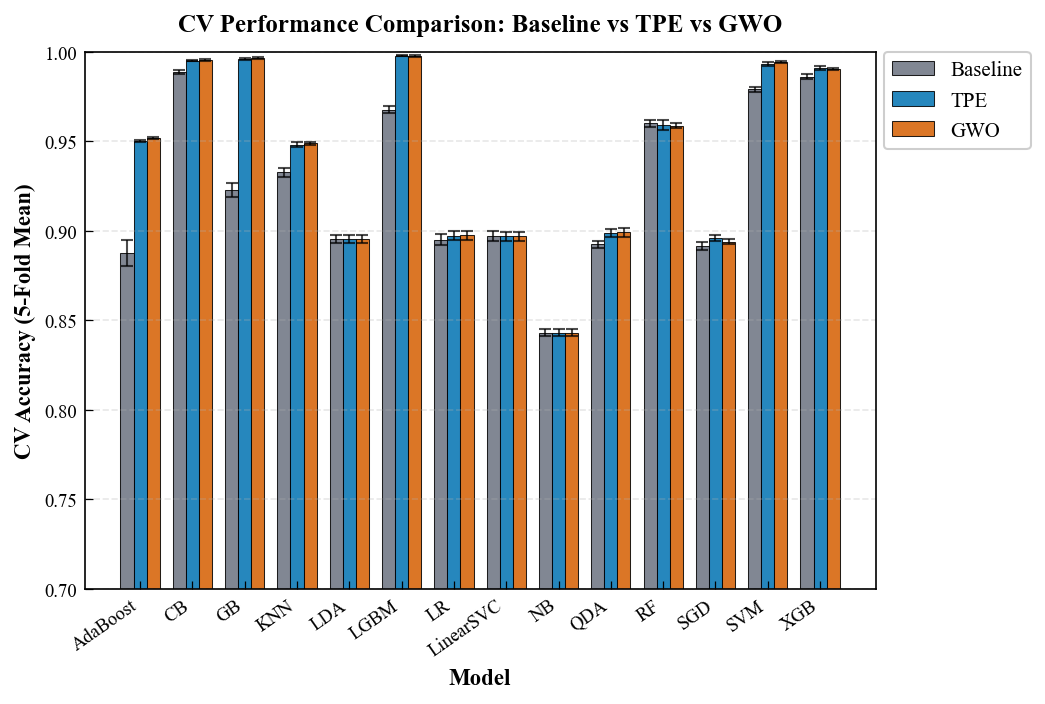

In [20]:
# 3.1 CV Performance Comparison Plot (PRIORITY 1: HIGHEST)
# Bar plot with error bars: 14 models × 3 methods

# Prepare data for plotting
models = sorted(baseline_models)
method_order = ['Baseline', 'TPE', 'GWO']

# Create figure with extra width for external legend
fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL * 1.15, 4.8))

x_positions = np.arange(len(models))
bar_width = 0.25

for idx, method in enumerate(method_order):
    method_data = comparison_cv_scores[comparison_cv_scores['Method'] == method]
    method_data = method_data.set_index('Model').loc[models]

    means = method_data['Mean'].values
    stds = method_data['Std'].values

    positions = x_positions + (idx - 1) * bar_width
    ax.bar(
        positions,
        means,
        bar_width,
        label=method,
        color=colors[method],
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5,
    )
    ax.errorbar(
        positions,
        means,
        yerr=stds,
        fmt='none',
        ecolor='black',
        capsize=3,
        capthick=1,
        linewidth=1,
        alpha=0.7,
    )

# Formatting
ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('CV Accuracy (5-Fold Mean)', fontsize=11, fontweight='bold')
ax.set_title('CV Performance Comparison: Baseline vs TPE vs GWO', fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(x_positions)
ax.set_xticklabels(models, rotation=35, ha='right', fontsize=9)
ax.set_ylim([0.70, 1.00])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Move legend outside so it never hides bars
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=10, framealpha=0.95, borderaxespad=0)

# Reserve right margin for legend
plt.tight_layout(rect=[0, 0, 0.86, 1])

# Save as PNG (300 DPI)
png_path = figures_dir / 'cv_performance_plot.png'
plt.savefig(png_path, dpi=300, bbox_inches='tight')
print(f"Saved: {png_path}")

# Save as PDF (vector)
pdf_path = figures_dir / 'cv_performance_plot.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")

plt.show()

Top 5 models by baseline CV mean: ['CB', 'XGB', 'SVM', 'LGBM', 'RF']
Saved: ..\results\figures\convergence_plot_top5.png
Saved: ..\results\figures\convergence_plot_top5.pdf


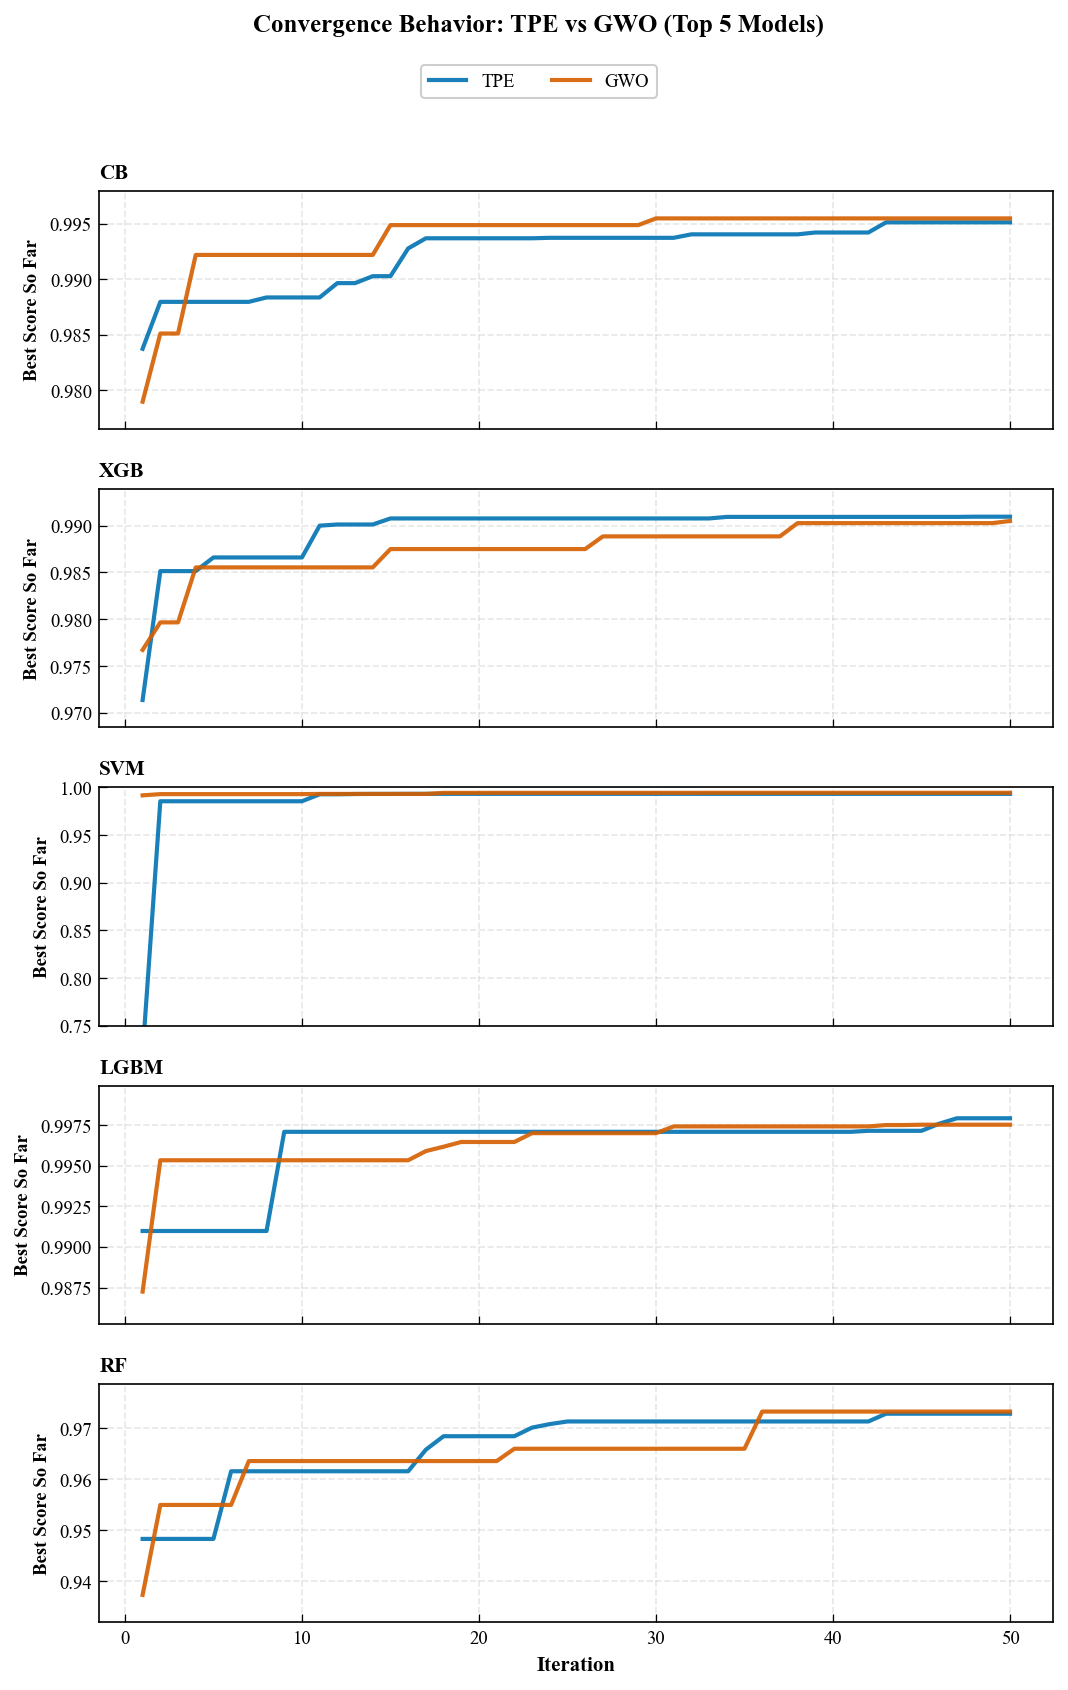

In [21]:
# 3.2 Convergence Comparison Plot (PRIORITY 2: HIGH)
# Top 5 models by baseline CV mean, each model on its own row

# Get top 5 models by baseline CV mean
top5_models = comparison_cv_scores[comparison_cv_scores['Method'] == 'Baseline'].nlargest(5, 'Mean')['Model'].tolist()
print(f"Top 5 models by baseline CV mean: {top5_models}")

# One model per line (5 rows x 1 column)
fig, axes = plt.subplots(5, 1, figsize=(IEEE_DOUBLE_COL, 11.0), sharex=True)

for idx, model in enumerate(top5_models):
    ax = axes[idx]

    # Get convergence data for this model
    tpe_data = comparison_convergence[
        (comparison_convergence['Model'] == model) & (comparison_convergence['Optimizer'] == 'TPE')
    ]
    gwo_data = comparison_convergence[
        (comparison_convergence['Model'] == model) & (comparison_convergence['Optimizer'] == 'GWO')
    ]

    # Plot convergence curves
    if len(tpe_data) > 0:
        ax.plot(
            tpe_data['Iteration'],
            tpe_data['Best_Score_So_Far'],
            color=CB_BLUE,
            linewidth=2,
            label='TPE',
            alpha=0.9,
        )

    if len(gwo_data) > 0:
        ax.plot(
            gwo_data['Iteration'],
            gwo_data['Best_Score_So_Far'],
            color=CB_ORANGE,
            linewidth=2,
            label='GWO',
            alpha=0.9,
        )

    # Per-row formatting
    ax.set_ylabel('Best Score So Far', fontsize=9, fontweight='bold')
    ax.set_title(f'{model}', fontsize=10, fontweight='bold', loc='left')
    ax.grid(alpha=0.3, linestyle='--')

    # Tight local y-range to improve readability for each model
    y_min = min(tpe_data['Best_Score_So_Far'].min(), gwo_data['Best_Score_So_Far'].min())
    y_max = max(tpe_data['Best_Score_So_Far'].max(), gwo_data['Best_Score_So_Far'].max())
    pad = max(0.002, (y_max - y_min) * 0.15)
    ax.set_ylim([max(0.75, y_min - pad), min(1.0, y_max + pad)])

axes[-1].set_xlabel('Iteration', fontsize=10, fontweight='bold')

# Shared legend outside plotting area to avoid overlap
fig.legend(['TPE', 'GWO'], loc='upper center', ncol=2, framealpha=0.95, bbox_to_anchor=(0.5, 0.995))
fig.suptitle('Convergence Behavior: TPE vs GWO (Top 5 Models)', fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save as PNG (300 DPI)
png_path = figures_dir / 'convergence_plot_top5.png'
plt.savefig(png_path, dpi=300, bbox_inches='tight')
print(f"Saved: {png_path}")

# Save as PDF (vector)
pdf_path = figures_dir / 'convergence_plot_top5.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")

plt.show()

Saved: ..\results\figures\runtime_plot.png
Saved: ..\results\figures\runtime_plot.pdf


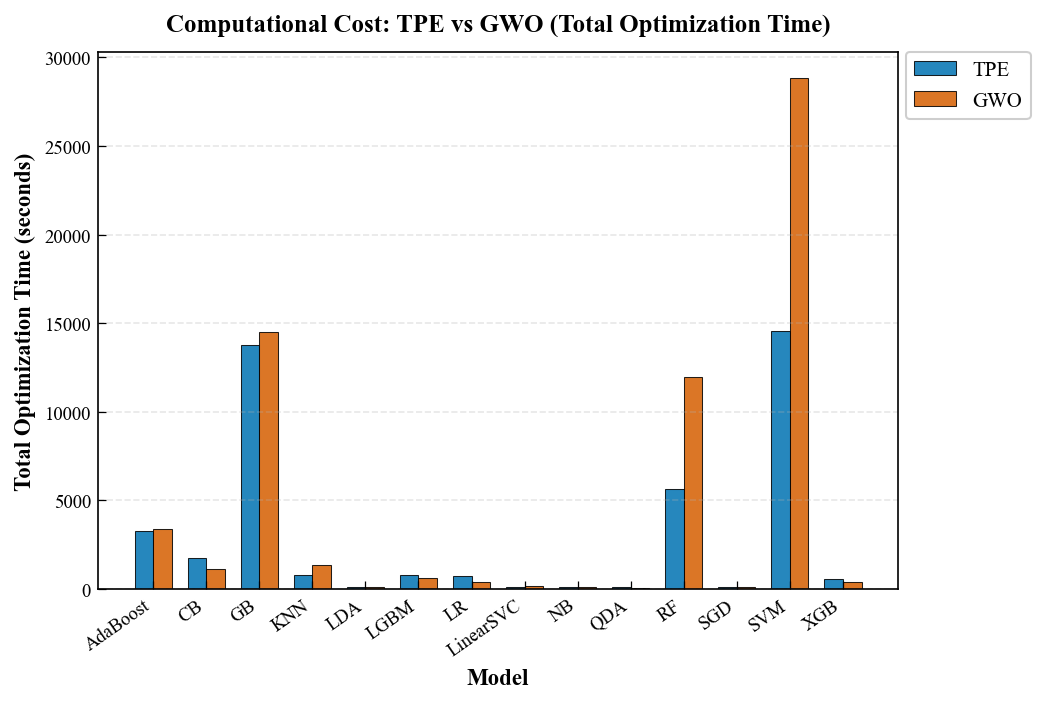

In [22]:
# 3.3 Runtime Comparison Plot (PRIORITY 3)
# Total optimization time: TPE vs GWO for all 14 models

fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL * 1.15, 4.8))

models = sorted(baseline_models)
x_positions = np.arange(len(models))
bar_width = 0.35

# Prepare data
runtime_by_model = comparison_runtime.set_index('Model').loc[models]

# Plot TPE vs GWO total times
tpe_times = runtime_by_model['TPE_Total_Time_Sec'].values
gwo_times = runtime_by_model['GWO_Total_Time_Sec'].values

ax.bar(
    x_positions - bar_width / 2,
    tpe_times,
    bar_width,
    label='TPE',
    color=CB_BLUE,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5,
)
ax.bar(
    x_positions + bar_width / 2,
    gwo_times,
    bar_width,
    label='GWO',
    color=CB_ORANGE,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5,
)

# Formatting
ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Optimization Time (seconds)', fontsize=11, fontweight='bold')
ax.set_title('Computational Cost: TPE vs GWO (Total Optimization Time)', fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(x_positions)
ax.set_xticklabels(models, rotation=35, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Move legend outside to avoid covering bars
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=10, framealpha=0.95, borderaxespad=0)

plt.tight_layout(rect=[0, 0, 0.86, 1])

# Save as PNG (300 DPI)
png_path = figures_dir / 'runtime_plot.png'
plt.savefig(png_path, dpi=300, bbox_inches='tight')
print(f"Saved: {png_path}")

# Save as PDF (vector)
pdf_path = figures_dir / 'runtime_plot.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")

plt.show()

Saved: ..\results\figures\improvement_plot.png
Saved: ..\results\figures\improvement_plot.pdf


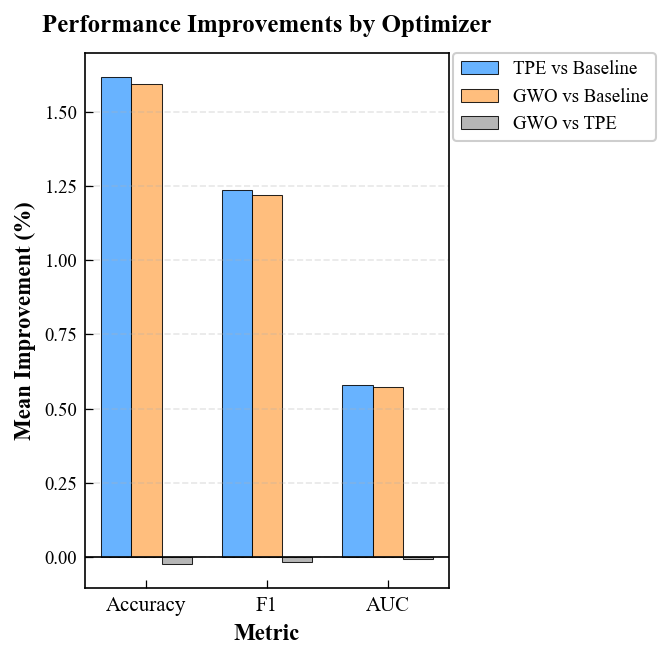

In [23]:
# 3.4 Improvement Summary Plot (PRIORITY 4: OPTIONAL)
# Mean improvements for key metrics: Baseline→TPE, Baseline→GWO, TPE vs GWO

# Filter to key metrics
key_metrics = ['Accuracy', 'F1', 'AUC']
imp_summary = comparison_improvement_summary[comparison_improvement_summary['Metric'].isin(key_metrics)]

fig, ax = plt.subplots(figsize=(IEEE_SINGLE_COL * 1.6, 4.5))

# Prepare data by comparison type
comparisons = ['TPE vs Baseline', 'GWO vs Baseline', 'GWO vs TPE']
x_positions = np.arange(len(key_metrics))
bar_width = 0.25

# Colors: TPE vs Baseline (light blue), GWO vs Baseline (light orange), GWO vs TPE (gray)
colors_imp = {
    'TPE vs Baseline': '#4DA6FF',
    'GWO vs Baseline': '#FFB366',
    'GWO vs TPE': '#A9A9A9',
}

for idx, comparison in enumerate(comparisons):
    comp_data = imp_summary[imp_summary['Comparison'] == comparison]
    comp_data = comp_data.set_index('Metric').loc[key_metrics]

    means = comp_data['Mean_Improvement_pct'].values
    positions = x_positions + (idx - 1) * bar_width

    ax.bar(
        positions,
        means,
        bar_width,
        label=comparison,
        color=colors_imp[comparison],
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5,
    )

# Add horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Formatting
ax.set_xlabel('Metric', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Improvement (%)', fontsize=11, fontweight='bold')
ax.set_title('Performance Improvements by Optimizer', fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(x_positions)
ax.set_xticklabels(key_metrics, fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Move legend outside to avoid covering bars
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=9, framealpha=0.95, borderaxespad=0)

plt.tight_layout(rect=[0, 0, 0.82, 1])

# Save as PNG (300 DPI)
png_path = figures_dir / 'improvement_plot.png'
plt.savefig(png_path, dpi=300, bbox_inches='tight')
print(f"Saved: {png_path}")

# Save as PDF (vector)
pdf_path = figures_dir / 'improvement_plot.pdf'
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"Saved: {pdf_path}")

plt.show()

## Summary: Outputs Created

All outputs have been generated and saved to `/results/tables/` and `/results/figures/`.

In [19]:
# Final Summary of All Outputs

print("="*70)
print("NOTEBOOK 06: COMPREHENSIVE COMPARISON - SUMMARY")
print("="*70)

print("\n✓ DATA AGGREGATION (Phase 1)")
print("  Tables created (7 CSV files):")
print(f"    1. comparison_cv_scores.csv (42 rows × 9 cols)")
print(f"    2. comparison_test_results.csv (42 rows × 18+ cols)")
print(f"    3. comparison_convergence.csv ({len(comparison_convergence)} rows)")
print(f"    4. comparison_runtime.csv (14 rows × 9 cols)")
print(f"    5. comparison_improvement_summary.csv ({len(comparison_improvement_summary)} rows)")
print(f"    6. comparison_summary_statistics.csv ({len(comparison_summary_statistics)} rows)")
print(f"    7. statistical_testing_input.csv (210 rows × 4 cols)")

print("\n✓ VISUALIZATIONS (Phase 3)")
print("  Figures created (4 PNG + 4 PDF files):")
print(f"    1. cv_performance_plot.png/.pdf - CV accuracy comparison (14 models)")
print(f"    2. convergence_plot_top5.png/.pdf - Convergence curves (top 5 models)")
print(f"    3. runtime_plot.png/.pdf - Optimization time comparison")
print(f"    4. improvement_plot.png/.pdf - Performance improvements (optional)")

print("\n✓ KEY STATISTICS")
print(f"  Models compared: {len(baseline_models)}")
print(f"  Methods: Baseline, TPE, GWO")
print(f"  CV folds: 5")
print(f"  Test metrics: {len(test_metrics)} (Accuracy, Precision, Recall, F1, AUC, LogLoss, Kappa, MCC)")

print("\n✓ READY FOR NOTEBOOK 07")
print(f"  Statistical testing input: statistical_testing_input.csv")
print(f"  Format: Long-form (Model, Method, Fold, Accuracy)")
print(f"  Ready for: Wilcoxon signed-rank tests, paired comparisons")

print("\n✓ DESIGN PRINCIPLES FOLLOWED")
print("  ✓ No model training or retraining")
print("  ✓ No hyperparameter optimization")
print("  ✓ No statistical tests (reserved for Notebook 07)")
print("  ✓ Consistent CV configuration (5-fold stratified)")
print("  ✓ Publication-quality visualizations (300 DPI, journal style)")
print("  ✓ Consistent color scheme (Baseline: gray, TPE: blue, GWO: orange)")

print("\n" + "="*70)
print("NOTEBOOK 06 EXECUTION COMPLETE ✓")
print("="*70)

NOTEBOOK 06: COMPREHENSIVE COMPARISON - SUMMARY

✓ DATA AGGREGATION (Phase 1)
  Tables created (7 CSV files):
    1. comparison_cv_scores.csv (42 rows × 9 cols)
    2. comparison_test_results.csv (42 rows × 18+ cols)
    3. comparison_convergence.csv (1400 rows)
    4. comparison_runtime.csv (14 rows × 9 cols)
    5. comparison_improvement_summary.csv (24 rows)
    6. comparison_summary_statistics.csv (15 rows)
    7. statistical_testing_input.csv (210 rows × 4 cols)

✓ VISUALIZATIONS (Phase 3)
  Figures created (4 PNG + 4 PDF files):
    1. cv_performance_plot.png/.pdf - CV accuracy comparison (14 models)
    2. convergence_plot_top5.png/.pdf - Convergence curves (top 5 models)
    3. runtime_plot.png/.pdf - Optimization time comparison
    4. improvement_plot.png/.pdf - Performance improvements (optional)

✓ KEY STATISTICS
  Models compared: 14
  Methods: Baseline, TPE, GWO
  CV folds: 5
  Test metrics: 8 (Accuracy, Precision, Recall, F1, AUC, LogLoss, Kappa, MCC)

✓ READY FOR NOTEBO